## AI POWERED FOOD INSIGHT SYSTEM

#Load the File

In [ ]:
#Get Tenssorflow Datasets
import tensorflow_datasets as tfds
import tensorflow as tf

In [ ]:
(train_data,test_data),ds_info=tfds.load(name="food101",
                                         split=("train","validation"),
                                         shuffle_files=True,
                                         as_supervised=True,
                                         with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.YZ8FJN_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.YZ8FJN_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


#Use Tensorflow Datasets to Download Data

In [ ]:
#Checking if "food101" is there
datasets_list=tfds.list_builders()
print("food101" in datasets_list)

True


In [ ]:
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [ ]:
class_names=ds_info.features["label"].names
class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheesecake',
 'cheese_plate',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

#Exploring the Food101 with the Tensorflow Datasets

To become one with the data we want to find:
* Class Names
* The shape of our Input Data(import data)
* The datatype of our input data
* What the labels looks like(Like are they one hot encoded or label encoded)
* Do the labels match up with class names

In [ ]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
#Take one sample of training data
train_one_sample=train_data.take(1)
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
for image,label in train_one_sample:
  print(image.shape,label.shape
        )

(512, 512, 3) ()


In [ ]:
#Output info about our training sample


for image, label in train_one_sample:
  print(f"""
  Image shape: {image.shape}
  Image dtype: {image.dtype}
  Target class from Food101 (tensor form): {label}
  Class name (str form): {class_names[label.numpy()]}
        """)


  Image shape: (306, 512, 3)
  Image dtype: <dtype: 'uint8'>
  Target class from Food101 (tensor form): 29
  Class name (str form): cup_cakes
        


In [ ]:
#what about our image tensor looks like
image[:2]

<tf.Tensor: shape=(2, 512, 3), dtype=uint8, numpy=
array([[[199, 100,  15],
        [192,  91,   9],
        [202,  95,  23],
        ...,
        [238, 196, 124],
        [237, 195, 123],
        [236, 194, 122]],

       [[210, 110,  25],
        [207, 105,  23],
        [194,  86,  13],
        ...,
        [238, 196, 124],
        [236, 194, 122],
        [235, 193, 121]]], dtype=uint8)>

#Finding Min and Max Value of our Tensor

In [ ]:
import tensorflow as tf
tf.reduce_min(image),tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

##Plot an Image from Tensorflow Datasets

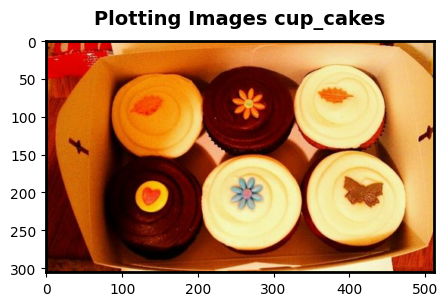

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg



plt.figure(figsize=(5,7))
plt.imshow(image, cmap=plt.cm.hot, interpolation="bilinear")
plt.title(f"Plotting Images {class_names[label.numpy()]}",fontsize=14,fontweight="bold",pad=12)


# Add a border around the image
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(2)


plt.show()

In [ ]:
print(spine.__dict__)

{'_stale': False, 'stale_callback': <function _stale_axes_callback at 0x7e38ba8ad940>, '_axes': <Axes: title={'center': 'Plotting Images cup_cakes'}>, '_parent_figure': <Figure size 500x700 with 1 Axes>, '_transform': <matplotlib.transforms.BlendedGenericTransform object at 0x7e37fea35100>, '_transformSet': True, '_visible': True, '_animated': False, '_alpha': None, 'clipbox': None, '_clippath': None, '_clipon': True, '_label': '', '_picker': None, '_rasterized': False, '_agg_filter': None, '_mouseover': False, '_callbacks': <matplotlib.cbook.CallbackRegistry object at 0x7e37fea35760>, '_remove_method': None, '_url': None, '_gid': None, '_snap': None, '_sketch': None, '_path_effects': [], '_sticky_edges': _XYPair(x=[], y=[]), '_in_layout': True, '_hatch_color': (0.0, 0.0, 0.0, 1.0), '_hatch_linewidth': 1.0, '_fill': True, '_original_edgecolor': 'black', '_edgecolor': (0.0, 0.0, 0.0, 1.0), '_original_facecolor': 'none', '_facecolor': (0.0, 0.0, 0.0, 0.0), '_linewidth': 2.0, '_unscaled_d

#Create a Preprocessing Function for our Data

The Preprocessing Function takes several things into the play:
Neural Network perform better when data is normalized and batched.

But tensorflow datasets doesnt comes in this forma.

What we know about our data:

* "uint" DataType
* Comprised of all different image sizes.
* Not Scaled (the pixel values are between 0 & 255)

So we have to write function that includes:
* Data in "float32" type(or for mixed precision 'float16' or 'float32')
* For Batches, tensorflow likes all of this tensors in same size.
* Scaled(Between 0 & 1) often tehcnique is called Normalization

For this we are going to use EfficientNetBX(no need to rescale coz it has builtin):
1. Reshape our images to all same size.
2. Convert the dtype of our image tensors from 'uint8' to 'float16'


In [ ]:
#Make a Function for preprocessing the image
def preprocess_img(image, label, img_size=224):
    image = tf.image.resize(image, [img_size, img_size])
    image = tf.cast(image, tf.float32)
    return image, label

In [ ]:
preprocessed_img = preprocess_img(image, label)[0] #Here O means images that referes to above function image,label
print(f"Image before preprocessing:\n {image[:2]}...,\nShape: {image.shape},\nDatatype: {image.dtype}\n")
print(f"Image after preprocessing:\n {preprocessed_img[:2]}...,\nShape: {preprocessed_img.shape},\nDatatype: {preprocessed_img.dtype}")

Image before preprocessing:
 [[[199 100  15]
  [192  91   9]
  [202  95  23]
  ...
  [238 196 124]
  [237 195 123]
  [236 194 122]]

 [[210 110  25]
  [207 105  23]
  [194  86  13]
  ...
  [238 196 124]
  [236 194 122]
  [235 193 121]]]...,
Shape: (306, 512, 3),
Datatype: <dtype: 'uint8'>

Image after preprocessing:
 [[[196.98405    96.515305   13.443877 ]
  [185.15625    75.776146   10.615431 ]
  [176.09981    62.711414    9.320153 ]
  ...
  [237.2455    192.6027    122.24549  ]
  [238.        196.        124.       ]
  [236.4598    194.4598    122.459785 ]]

 [[209.20886   106.47194    23.047512 ]
  [168.58833    56.285706    0.8501243]
  [166.6894     53.45121     2.8341837]
  ...
  [236.62468   192.2172    121.85998  ]
  [238.50987   195.96077   125.60809  ]
  [235.9958    193.4467    123.09402  ]]]...,
Shape: (224, 224, 3),
Datatype: <dtype: 'float32'>


#Plotting Original and Preprocessed Image

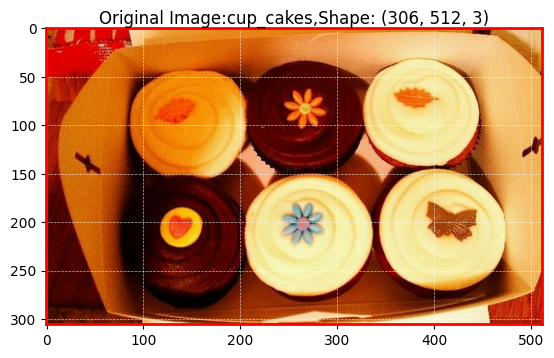

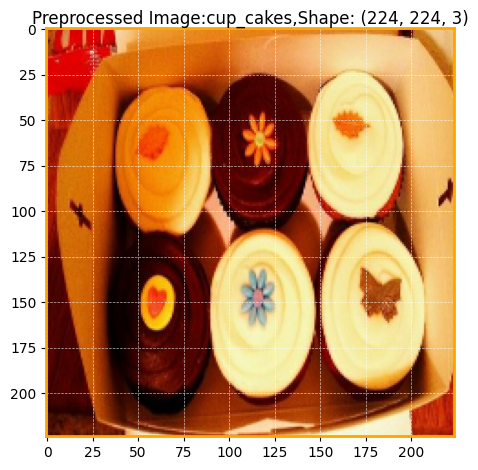

In [ ]:
plt.figure()

#First Plot Image

plt.title(f"Original Image:{class_names[label]},Shape: {image.shape}",fontsize=12,pad=2)
ax=plt.gca()
for spine in ax.spines.values():
  spine.set_edgecolor("red")
  spine.set_linewidth(2)
plt.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.7)
plt.imshow(image)

#Plot Second Plot
plt.figure()
plt.title(f"Preprocessed Image:{class_names[label]},Shape: {preprocessed_img.shape}",fontsize=12,pad=2)
ax=plt.gca()
for spine in ax.spines.values():
  spine.set_edgecolor("orange")
  spine.set_linewidth(2)
  plt.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.7)
plt.imshow(preprocessed_img/255.0)
plt.tight_layout()


#Applying Data Augmentation

In [ ]:
from keras import layers
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    ],name="data_augmentation")

#Plotting Images before and After Data Augmentation

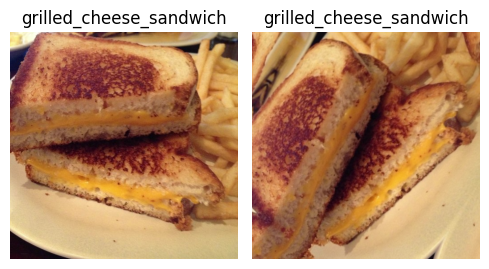

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

for images, labels in train_data.take(1):

    # Original image
    plt.subplot(1, 2, 1)
    img1 = images.numpy().astype("float32") / 255.0
    plt.imshow(img1)
    plt.title(f"{class_names[labels.numpy()]}")
    plt.axis("off")

    # Augmented image
    augmented_images = data_augmentation(images,
        training=True
    )

    plt.subplot(1, 2, 2)
    img2 = tf.squeeze(augmented_images).numpy().astype("float32") / 255.0
    plt.imshow(img2)
    plt.title(f"{class_names[labels.numpy()]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


#Batch and Prepare Datasets First

* map() - maps a predefined function to a target dataset (e.g. preprocess_img() to our image tensors)
* shuffle() - randomly shuffles the elements of a target dataset up buffer_size (ideally, the buffer_size is equal to the size of the dataset, however, this may have implications on memory)
* batch() - turns elements of a target dataset into batches (size defined by parameter batch_size)
* prefetch() - prepares subsequent batches of data whilst other batches of data are being computed on (improves data loading speed but costs memory)
* Extra: cache() - caches (saves them for later) elements in a target dataset, saving loading time (will only work if your dataset is small enough to fit in memory, standard Colab instances only have 12GB of memory)

In [ ]:
#Map Preprocessing function to training (and parallelize)
train_data=train_data.map(map_func=preprocess_img,num_parallel_calls=tf.data.AUTOTUNE)

#Map Preprocessing function to data augmentation(and parallelize) - AFTER preprocessing but BEFORE batching
train_data=train_data.map(map_func=lambda x,y:(data_augmentation(x,training=True),y),
                          num_parallel_calls=tf.data.AUTOTUNE)

#Shuffle train_data and turn it into batch and prefetch(load it faster)
train_data=train_data.shuffle(buffer_size=200).batch(batch_size=16).prefetch(tf.data.AUTOTUNE)

#Map preprocessing function to test data
test_data=test_data.map(map_func=preprocess_img,num_parallel_calls=tf.data.AUTOTUNE).batch(16).prefetch(tf.data.AUTOTUNE)

# Creating Model Callbacks

Here we are going to create a couple of callbacks to help us while our model trains:

* TensorBoard Callback to log training results(so we can visualize it later when we needs)

* Model Checkpoint Callback to save our model's progress after feature extraction.

In [ ]:
#Creating Tensorboard
import datetime

def create_tensorboard_callback(dir_name,experiment_name):
  log_dir=dir_name+"/"+experiment_name+"/"+datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback=tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"Savings TensorBoard log files to:{log_dir}")
  return tensorboard_callback

In [ ]:


#Create ModelCheckpoint callback to save a model progress during training.
checkpoint_path="model_checkpoints/cp.cpkt.weights.h5"
checkpoint_callback=tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                       monitor="val_accuracy",
                                                       save_best_only=True,
                                                       save_weights_only=True,
                                                       verbose=0)

In [ ]:
#Early Stopping Callback
early_stopping_callback=tf.keras.callbacks.EarlyStopping(
  monitor="val_loss",
  patience=3,
  verbose=1,
  restore_best_weights=True
)

##Setup Mixed Precision Training

Mixed Precision is a combination of float16 and float32 to speed up model performance.

In [ ]:
from tensorflow.keras import mixed_precision

#Set global data policy to mixed precision
mixed_precision.set_global_policy("mixed_float16")

In [ ]:
#Build a Feature Extraction Model

from tensorflow.keras import layers

#Create Base Model
input_shape=(224,224,3)
base_model=tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable=False

#Create Functional Model
inputs=tf.keras.layers.Input(shape=input_shape,name="input_layer")

#Note: EfficientNetBX Models has built in rescaling so we dont have to do this one.
x=base_model(inputs,training=False)
x=layers.GlobalAveragePooling2D()(x)
x=layers.Dense(len(class_names))(x)

outputs=layers.Activation("softmax",dtype=tf.float32,name="softmax_float32")(x) #Here dtype belongs to Mixed Precision
model=tf.keras.Model(inputs,outputs)

#Compile the Model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Checking layer dtype policies(are we using mixed_precision)
for layer in model.layers:
  print(layer.name,layer.trainable,layer.dtype,layer.dtype_policy)

input_layer True float32 <DTypePolicy "mixed_float16">
efficientnetb0 False float32 <DTypePolicy "mixed_float16">
global_average_pooling2d True float32 <DTypePolicy "mixed_float16">
dense True float32 <DTypePolicy "mixed_float16">
softmax_float32 True float32 <DTypePolicy "float32">


In [ ]:
#Check the dtype_policy attributes of layers in base_model
for layer in model.layers[1].layers:
  print(layer.name,layer.trainable,layer.dtype,layer.dtype_policy)

input_layer_1 False float32 <DTypePolicy "mixed_float16">
rescaling False float32 <DTypePolicy "mixed_float16">
normalization False float32 <DTypePolicy "mixed_float16">
rescaling_1 False float32 <DTypePolicy "mixed_float16">
stem_conv_pad False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_dwconv False float32 <DTypePolicy "mixed_float16">
block1a_bn False float32 <DTypePolicy "mixed_float16">
block1a_activation False float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze False float32 <DTypePolicy "mixed_float16">
block1a_se_reshape False float32 <DTypePolicy "mixed_float16">
block1a_se_reduce False float32 <DTypePolicy "mixed_float16">
block1a_se_expand False float32 <DTypePolicy "mixed_float16">
block1a_se_excite False float32 <DTypePolicy "mixed_float16">
block1a_project_conv False float32 <DTypePolicy "mixed_float1

#Plot any Random 9 images from our Dataset

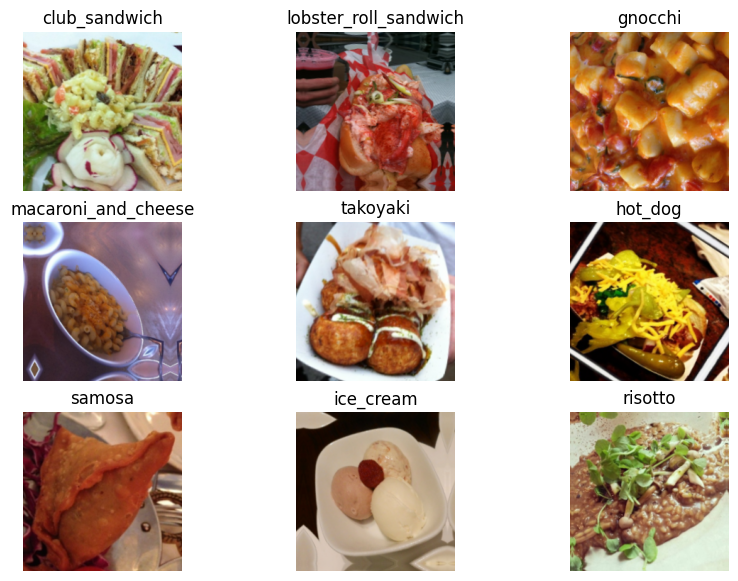

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

samples=list(train_data.shuffle(200).take(9))

for i in range(9):
    img, label = samples[i]

    plt.subplot(3,3,i+1)
    plt.imshow(img[0].numpy().astype("uint8")) # Display the first image from the batch
    plt.title(class_names[label.numpy()[0]]) # Get the label for the first image in the batch
    plt.axis("off")

plt.show()


#Fit the Feature Extraction Model

If our goal is to fine-tune a pretrained Model, our order to so is:
1. Build a Feature Extraction Model(train a couple of output layers with base frozen layers)
2. Fint-Tune some of the frozen layers

#Fine-Tuning Previous Model

In [ ]:
#Fit the Feature Extraction Model
initial_epochs=5
history_101_model=model.fit(train_data,
                            epochs=initial_epochs,
                            steps_per_epoch=len(train_data),
                            validation_data=test_data,
                            validation_steps=int(0.15* len(test_data)),
                            callbacks=[create_tensorboard_callback(dir_name="training_logs",
                                                                  experiment_name="efficientnetb0_101"
                                                                 ),
                                       checkpoint_callback,
                                       early_stopping_callback])

Savings TensorBoard log files to:training_logs/efficientnetb0_101/20260506-000215
Epoch 1/5
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 927s 183ms/step - accuracy: 0.4989 - loss: 2.0455 - val_accuracy: 0.6581 - val_loss: 1.2365
Epoch 2/5
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 818s 172ms/step - accuracy: 0.5886 - loss: 1.6148 - val_accuracy: 0.6811 - val_loss: 1.1505
Epoch 3/5
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 819s 172ms/step - accuracy: 0.6129 - loss: 1.5037 - val_accuracy: 0.6973 - val_loss: 1.0954
Epoch 4/5
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 823s 173ms/step - accuracy: 0.6270 - loss: 1.4370 - val_accuracy: 0.7034 - val_loss: 1.0865
Epoch 5/5
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 822s 173ms/step - accuracy: 0.6372 - loss: 1.3961 - val_accuracy: 0.7060 - val_loss: 1.0669
Restoring model weights from the end of the best epoch: 5.


In [ ]:
base_model.trainable=True

#Freeze all layers except last 5
for layer in base_model.layers[:5]:
  layer.trainable=False

#Recompile the Model(always recompile the model when you make any adjustments)
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])


In [ ]:
#Fine-tune for another 7 epochs
fine_tune_epochs=initial_epochs + 3

#Refit the Model(same model except with more trainable layers)
fine_tune_model=model.fit(train_data,
                          epochs=fine_tune_epochs,
                          validation_data=test_data,
                          initial_epoch=history_101_model.epoch[-1],
                          validation_steps=int(0.25*len(test_data)),
                          callbacks=[create_tensorboard_callback("transfer_learning","fine_tune_last_7_epoch"),
                                   checkpoint_callback,
                                     early_stopping_callback])


Savings TensorBoard log files to:transfer_learning/fine_tune_last_7_epoch/20260506-011225
Epoch 5/8
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 1280s 229ms/step - accuracy: 0.6230 - loss: 1.4559 - val_accuracy: 0.7265 - val_loss: 0.9780
Epoch 6/8
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 944s 199ms/step - accuracy: 0.7161 - loss: 1.0681 - val_accuracy: 0.7757 - val_loss: 0.7971
Epoch 7/8
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 947s 200ms/step - accuracy: 0.7520 - loss: 0.9181 - val_accuracy: 0.7778 - val_loss: 0.7945
Epoch 8/8
4735/4735 ━━━━━━━━━━━━━━━━━━━━ 937s 197ms/step - accuracy: 0.7771 - loss: 0.8118 - val_accuracy: 0.7819 - val_loss: 0.7942
Restoring model weights from the end of the best epoch: 8.


In [ ]:
#Lets Evaluate on Full Test Data
history_101_model=model.evaluate(test_data)

1579/1579 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7821 - loss: 0.8042


#Extracting y_preds from test_data

In [ ]:
y_true=[]

for images,labels in test_data:
  y_true.extend(labels.numpy())

#Model Predictions on Test Data

In [ ]:
y_preds=model.predict(test_data,verbose=1)
y_preds[:10]

1579/1579 ━━━━━━━━━━━━━━━━━━━━ 88s 40ms/step


array([[1.9771231e-03, 1.3990459e-04, 7.5472868e-05, ..., 4.2006974e-05,
        1.9688274e-05, 1.8219553e-01],
       [1.9474550e-03, 1.5098645e-07, 5.5469549e-04, ..., 2.1511089e-04,
        5.2699454e-07, 8.9483228e-06],
       [2.6589098e-06, 2.5918612e-07, 2.8185184e-08, ..., 6.4788378e-06,
        2.7064658e-05, 1.5753520e-06],
       ...,
       [2.0609838e-05, 8.4050802e-09, 7.9913019e-07, ..., 6.9868925e-04,
        5.6871623e-09, 3.6967958e-03],
       [6.6235814e-05, 1.4534593e-06, 2.4276901e-04, ..., 1.4710313e-04,
        1.1299151e-05, 3.2877497e-07],
       [1.1262234e-05, 2.4412179e-07, 2.2317870e-06, ..., 1.3453372e-08,
        1.0046227e-05, 1.1730901e-05]], dtype=float32)

In [ ]:
y_preds=tf.argmax(y_preds,axis=1).numpy()
y_preds[:10]

array([28, 12, 34, 96, 10, 32, 96, 42, 63, 91])

#Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def confusion_matrix_plot(y_true,y_preds,classes=None,figsize=(10,10),text_size=15,norm=False):
  """
  Make Labelled Confusion Matrix Plot comparing predictions with ground truth labels

  if classes is passed, confusion matrix will be labelled else integer class value will be used.

  Arguments:
  y_true: Array of truth labels.(must be same shape of y_pred)
  y_pred: Array of Predicted Labels(must be same shape as y_true)
  classes: Array of class names (eg: String Form) or integer label will be used
  figsize=Size of Output Figure
  text_size=Size of Output Figure Text
  norm: Normalizes the value or not (default=False)
.

  Returns: A labelled confusion Matrix plot comparing y_preds and y_true labels.
  """

  #Create Confusion Matrix

  cm=confusion_matrix(y_true,y_preds)
  cm_norm=cm.astype("float") /cm.sum(axis=1)[:,np.newaxis] #Normalize it

  n_classes=cm.shape[0] #Find the number of classes we are dealing with

  #Plot the Figure
  fig,ax=plt.subplots(figsize=figsize)
  cax=ax.matshow(cm,cmap=plt.cm.Oranges) #colors will represent how "correct" a class is
  fig.colorbar(cax)
  #Are there a list of classes
  if classes:
    labels=classes
  else:
    labels=np.arange(cm.shape[0])


  #Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted Label",
         ylabel="True Label",
         xticks=np.arange(n_classes),
         yticks=np.arange(n_classes),
         xticklabels=labels,
         yticklabels=labels)

  #Make x-axis labbel appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  #Rotate xticks for readibility & increase font size(required due to large such confusion matrix)
  plt.xticks(rotation=70,fontsize=text_size)
  plt.yticks(fontsize=text_size)

  #Set Thresolds
  thresold=(cm.max() + cm.min()) // 2.

  #Plot the text on each cell
  for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
    if norm:
      plt.text(j,i,f"{cm[i,j]}({cm_norm[i,j]*100:.1f}%)",
               horizontalalignment="center",
               color="white" if cm[i,j]>thresold else "black",
               size=text_size)

    else:
      plt.text(j,i,f"{cm[i,j]}",
              horizontalalignment="center",
               color="white" if cm[i,j]>thresold else "black",
               size=text_size)



In [ ]:
confusion_matrix_plot(y_true,
                          y_preds,
                          classes=class_names,
                          figsize=(100,100),
                          text_size=15,
                      norm=False)

#Top 100 most wrong Predictions

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd



# Create DataFrame
pred_df = pd.DataFrame({
    "y_true": y_true,
    "y_pred": y_preds,
    "y_true_classname": [class_names[i] for i in y_true],
    "y_pred_classname": [class_names[i] for i in y_preds]
})

# Filter only wrong predictions
wrong_df = pred_df[pred_df["y_true"] != pred_df["y_pred"]]

# Take top 100 wrong predictions (no confidence, just first 100)
top_100_wrong = wrong_df.head(100)

# Optional: check
print(top_100_wrong.head(81))

    y_true  y_pred    y_true_classname   y_pred_classname
2        4      34        beef_tartare      eggs_benedict
3       66      96              nachos              tacos
4       55      10             hot_dog         bruschetta
6       19      96  chicken_quesadilla              tacos
10      16     100          cheesecake            waffles
..     ...     ...                 ...                ...
84      23      33             churros            edamame
85      78      32             poutine          dumplings
86      13      69       caprese_salad            oysters
87      41      54   french_onion_soup  hot_and_sour_soup
88      27      88        creme_brulee      seaweed_salad

[81 rows x 4 columns]


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

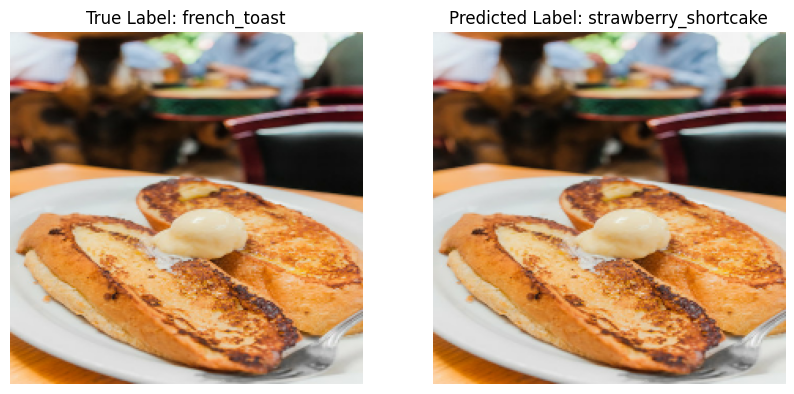

In [ ]:
#Visualizng Side by Side True vs Predicted Label
import random

wrong_indices=top_100_wrong.index.tolist()

test_images=[]
test_labels=[]

for i,(images,labels) in enumerate(test_data.unbatch()):
  if i in wrong_indices:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

  if i > wrong_indices[-1]:
    break

idx=random.randint(0,len(test_images)-1)


plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(test_images[idx].astype("uint8"))
plt.title(f"True Label: {class_names[test_labels[idx]]}")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(test_images[idx].astype("uint8"))
plt.title(f"Predicted Label: {class_names[top_100_wrong.iloc[idx]['y_pred']]}")
plt.axis("off")

#Applying Heatmap to our Model via Grad-Cam

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,452,816 (47.50 MB)

 Trainable params: 4,136,929 (15.78 MB)

 Non-trainable params: 42,023 (164.16 KB)

 Optimizer params: 8,273,864 (31.56 MB)

In [ ]:
import matplotlib.pyplot as plt
import cv2


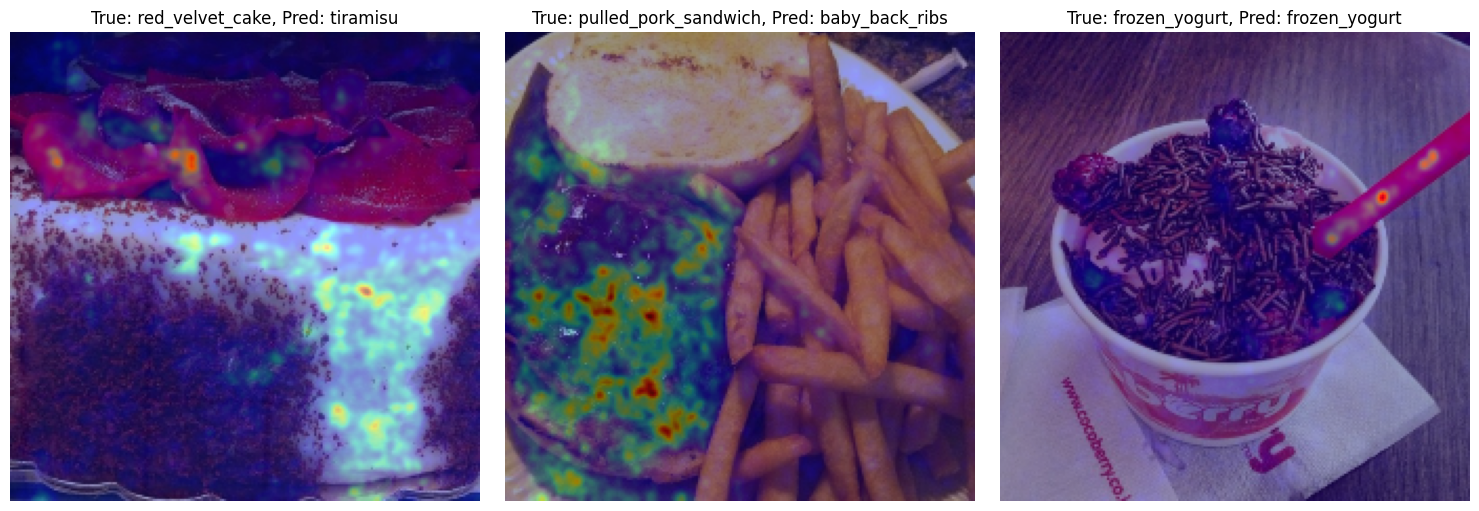

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(15,5))

i = 0
for image, label in test_data.unbatch().take(3):
    img = tf.identity(image)

    # Resize & preprocess
    img_resized = tf.image.resize(img, (224,224))
    img_batch = tf.expand_dims(img_resized, axis=0)
    img_batch = tf.cast(img_batch, tf.float32)
    # ❌ Removed preprocess_input — EfficientNet handles this internally

    # Predict class
    preds = model.predict(img_batch, verbose=0)
    class_index = np.argmax(preds[0])

    # Grad-CAM
    with tf.GradientTape() as tape:
        tape.watch(img_batch)
        predictions = model(img_batch)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, img_batch)
    heatmap = tf.reduce_sum(tf.abs(grads[0]), axis=-1)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    heatmap = cv2.GaussianBlur(heatmap.numpy(), (7,7), 0)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    # Display
    plt.subplot(1, 3, i+1)
    plt.imshow(img_resized.numpy().astype("uint8"))
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.axis("off")
    plt.title(f"True: {class_names[label.numpy()]}, Pred: {class_names[class_index]}")

    i += 1

plt.tight_layout()
plt.show()

#Plotting Loss Curve vs Accuracy Curve

### View TensorBoard Logs

To view the logs for the fine-tuned model, we can launch TensorBoard and point it to the log directory.

In [ ]:
def plot_loss_curves(history):

  """
  Returns separate loss curves for training and validation metrics.
  """

  loss=history.history["loss"]
  val_loss=history.history["val_loss"]

  accuracy=history.history["accuracy"]
  val_accuracy=history.history["val_accuracy"]

  epochs=range(len(history.history["loss"]))

  #Plot Loss
  plt.figure()
  plt.plot(epochs,loss,label="training_loss")
  plt.plot(epochs,val_loss,label="val_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  #Plot Accuracy
  plt.figure()
  plt.plot(epochs,accuracy,label="training_accuracy")
  plt.plot(epochs,val_accuracy,label="val_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

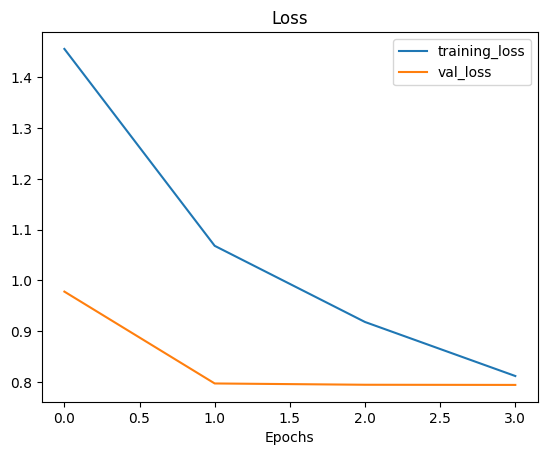

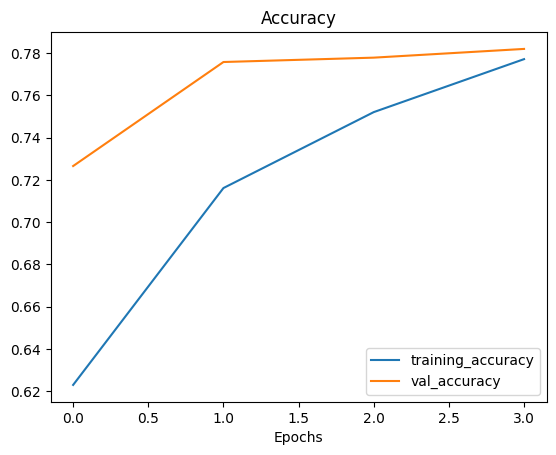

In [ ]:
plot_loss_curves(fine_tune_model)

#Save the Model

In [ ]:
model.save("food_vision_fine_tuned_model.keras")

#Loading the Model

In [ ]:
import tensorflow as tf
loaded_model = tf.keras.models.load_model("food_vision_fine_tuned_model.keras")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copy('food_vision_fine_tuned_model.keras', '/content/drive/MyDrive/')
print("Done!")

Mounted at /content/drive
Done!


#Fetch Real Nutrition Data using USDA FoodData Central API


In [ ]:
!pip install fastapi uvicorn python-multipart pyngrok nest-asyncio -q

In [ ]:
%%writefile main.py

from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
from fastapi.staticfiles import StaticFiles
from fastapi.responses import FileResponse

import tensorflow as tf
import numpy as np
import requests

app = FastAPI()

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

model = None
class_names = []

# 🔑 YOUR API KEYS (demo version)
USDA_API_KEY = "dkXt1JvOiDoM1NRHg7OPMQ2lJzSGzqvaWm9OYMIh"
GROQ_API_KEY = "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"


# ================= LOAD MODEL =================
@app.on_event("startup")
def load_model():
    global model, class_names

    model = tf.keras.models.load_model("/content/food_vision_fine_tuned_model.keras")


    import tensorflow_datasets as tfds
    class_names = tfds.builder("food101").info.features["label"].names

    print("✅ MODEL LOADED:", model is not None)


# ================= IMAGE PREPROCESS =================
def preprocess_image(image_bytes):
    img = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, axis=0)
    return img

# ================= NUTRITION API =================
def get_nutrition(food_name):
    try:
        res = requests.get(
            "https://api.nal.usda.gov/fdc/v1/foods/search",
            params={
                "api_key": USDA_API_KEY,
                "query": food_name
            },
            timeout=5
        )

        data = res.json()

        if "foods" in data and len(data["foods"]) > 0:
            return data["foods"][0]

    except:
        pass

    return None


# ================= AI INSIGHT =================
def generate_insight(food_name):
    try:
        res = requests.post(
            "https://api.groq.com/openai/v1/chat/completions",
            headers={
                "Authorization": f"Bearer {GROQ_API_KEY}",
                "Content-Type": "application/json"
            },
            json={
                "model": "llama-3.3-70b-versatile",
                "messages": [{
                    "role": "user",
                    "content": f"Give one fun 25-word fact about {food_name.replace('_',' ')} with emoji."
                }],
                "max_tokens": 80
            },
            timeout=8
        )

        data = res.json()

        if "choices" in data:
            return data["choices"][0]["message"]["content"]

    except:
        pass

    return f"Enjoy your {food_name.replace('_',' ')} 🍽️"


# ================= MAIN API =================
@app.post("/analyze-photo")
async def analyze_photo(file: UploadFile = File(...)):

    if model is None:
        return {"error": "Model not loaded"}

    image_bytes = await file.read()
    processed = preprocess_image(image_bytes)

    preds = model.predict(processed, verbose=0)
    idx = int(np.argmax(preds[0]))
    confidence = float(np.max(preds[0]))

    food_name = class_names[idx] if idx < len(class_names) else "unknown"

    # nutrition
    nutrition_data = get_nutrition(food_name)
    nutrients = []

    if nutrition_data and "foodNutrients" in nutrition_data:
        for n in nutrition_data["foodNutrients"][:5]:
            nutrients.append({
                "name": n.get("nutrientName", ""),
                "value": n.get("value", 0),
                "unit": n.get("unitName", "")
            })

    # insight
    insight = generate_insight(food_name)

    return {
        "food": food_name.replace("_", " ").title(),
        "confidence": round(confidence * 100, 1),
        "nutrients": nutrients,
        "insight": insight
    }


# ================= FRONTEND =================
app.mount("/static", StaticFiles(directory="static"), name="static")

@app.get("/")
def root():
    return FileResponse("static/index.html")

Writing main.py


In [ ]:
import os
os.makedirs("static", exist_ok=True)

with open("static/index.html", "w") as f:
    f.write("""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1.0"/>
  <title>Food Vision AI</title>
  <link href="https://fonts.googleapis.com/css2?family=Playfair+Display:ital,wght@0,700;1,400&family=DM+Sans:wght@300;400;500&display=swap" rel="stylesheet"/>
  <style>
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0; }
    :root {
      --bg: #0d0d0d; --surface: #161616; --card: #1e1e1e; --border: #2a2a2a;
      --accent: #e8c97e; --accent2: #d4845a; --text: #f0ece4; --muted: #888; --radius: 16px;
    }
    body { background: var(--bg); color: var(--text); font-family: 'DM Sans', sans-serif; min-height: 100vh; display: flex; flex-direction: column; align-items: center; }
    header { width: 100%; max-width: 680px; padding: 60px 24px 32px; text-align: center; }
    .tag { display: inline-block; font-size: 11px; font-weight: 500; letter-spacing: 0.15em; text-transform: uppercase; color: var(--accent); border: 1px solid var(--accent); border-radius: 100px; padding: 4px 14px; margin-bottom: 20px; }
    h1 { font-family: 'Playfair Display', serif; font-size: clamp(2.4rem, 6vw, 3.6rem); line-height: 1.1; margin-bottom: 14px; }
    h1 em { font-style: italic; color: var(--accent); }
    .subtitle { font-size: 15px; color: var(--muted); font-weight: 300; line-height: 1.6; }
    main { width: 100%; max-width: 680px; padding: 0 24px 80px; display: flex; flex-direction: column; gap: 16px; }
    .drop-zone { border: 1.5px dashed var(--border); border-radius: var(--radius); padding: 56px 24px; text-align: center; cursor: pointer; background: var(--surface); position: relative; transition: all 0.25s; }
    .drop-zone:hover { border-color: var(--accent); background: #1a1a16; }
    .drop-icon { font-size: 48px; margin-bottom: 14px; display: block; }
    .drop-zone h2 { font-family: 'Playfair Display', serif; font-size: 1.3rem; margin-bottom: 6px; }
    .drop-zone p { font-size: 13px; color: var(--muted); }
    .drop-zone input[type="file"] { position: absolute; inset: 0; opacity: 0; cursor: pointer; width: 100%; height: 100%; }
    .preview-wrap { display: none; position: relative; border-radius: var(--radius); overflow: hidden; }
    .preview-wrap img { width: 100%; max-height: 380px; object-fit: cover; display: block; }
    .preview-overlay { position: absolute; inset: 0; background: linear-gradient(to top, rgba(0,0,0,0.5) 0%, transparent 50%); }
    .change-btn { position: absolute; top: 14px; right: 14px; background: rgba(0,0,0,0.6); border: 1px solid rgba(255,255,255,0.15); color: #fff; font-family: 'DM Sans', sans-serif; font-size: 12px; padding: 6px 14px; border-radius: 100px; cursor: pointer; }
    .analyze-btn { display: none; width: 100%; padding: 18px; background: var(--accent); color: #0d0d0d; font-family: 'DM Sans', sans-serif; font-size: 15px; font-weight: 500; border: none; border-radius: var(--radius); cursor: pointer; transition: all 0.2s; }
    .analyze-btn:hover { background: #f0d896; transform: translateY(-1px); }
    .loading { display: none; text-align: center; padding: 48px; background: var(--surface); border-radius: var(--radius); }
    .spinner { width: 36px; height: 36px; border: 2px solid var(--border); border-top-color: var(--accent); border-radius: 50%; animation: spin 0.8s linear infinite; margin: 0 auto 16px; }
    .loading p { font-size: 13px; color: var(--muted); }
    .result-card { display: none; background: var(--card); border: 1px solid var(--border); border-radius: var(--radius); overflow: hidden; }
    .result-header { padding: 28px 28px 20px; border-bottom: 1px solid var(--border); display: flex; align-items: flex-start; justify-content: space-between; gap: 16px; }
    .food-name { font-family: 'Playfair Display', serif; font-size: 1.9rem; font-weight: 700; line-height: 1.1; }
    .confidence-pill { flex-shrink: 0; background: rgba(232,201,126,0.12); border: 1px solid rgba(232,201,126,0.3); color: var(--accent); font-size: 12px; font-weight: 500; padding: 5px 12px; border-radius: 100px; margin-top: 4px; }
    .insight-box { padding: 18px 28px; border-bottom: 1px solid var(--border); font-size: 14px; color: #b0a898; line-height: 1.6; font-style: italic; }
    .insight-box span { color: var(--accent2); margin-right: 6px; }
    .nutrients-section { padding: 22px 28px; }
    .nutrients-label { font-size: 11px; font-weight: 500; letter-spacing: 0.12em; text-transform: uppercase; color: var(--muted); margin-bottom: 16px; }
    .nutrients-grid { display: grid; grid-template-columns: repeat(auto-fill, minmax(115px, 1fr)); gap: 12px; }
    .nutrient-item { background: var(--surface); border-radius: 12px; padding: 14px; text-align: center; }
    .nutrient-value { font-family: 'Playfair Display', serif; font-size: 1.3rem; color: var(--accent); line-height: 1; margin-bottom: 4px; }
    .nutrient-unit { font-size: 10px; color: var(--muted); text-transform: uppercase; }
    .nutrient-name { font-size: 11px; color: var(--muted); margin-top: 4px; }
    .try-again-btn { display: none; width: 100%; padding: 14px; background: transparent; color: var(--muted); font-family: 'DM Sans', sans-serif; font-size: 14px; border: 1px solid var(--border); border-radius: var(--radius); cursor: pointer; transition: all 0.2s; }
    .try-again-btn:hover { border-color: var(--accent); color: var(--accent); }
    .error-box { display: none; background: rgba(220,80,60,0.1); border: 1px solid rgba(220,80,60,0.3); border-radius: var(--radius); padding: 20px; text-align: center; font-size: 14px; color: #e08070; }
    footer { width: 100%; text-align: center; padding: 20px; font-size: 12px; color: #444; }
    @keyframes spin { to { transform: rotate(360deg); } }
  </style>
</head>
<body>
<header>
  <div class="tag">✦ EfficientNet + USDA + Groq AI</div>
  <h1>Food <em>Vision</em> AI</h1>
  <p class="subtitle">Upload any food photo. Get instant AI identification,<br/>nutrition facts & a smart insight.</p>
</header>
<main>
  <div class="drop-zone" id="dropZone">
    <span class="drop-icon">🍽️</span>
    <h2>Drop your food photo here</h2>
    <p>or click to browse · JPG, PNG, WEBP</p>
    <input type="file" id="fileInput" accept="image/*"/>
  </div>
  <div class="preview-wrap" id="previewWrap">
    <img id="previewImg" src="" alt="preview"/>
    <div class="preview-overlay"></div>
    <button class="change-btn" onclick="resetUI()">✕ Change</button>
  </div>
  <button class="analyze-btn" id="analyzeBtn" onclick="analyzePhoto()">Analyze Food →</button>
  <div class="loading" id="loading"><div class="spinner"></div><p>Identifying your dish…</p></div>
  <div class="error-box" id="errorBox"></div>
  <div class="result-card" id="resultCard">
    <div class="result-header">
      <div class="food-name" id="foodName"></div>
      <div class="confidence-pill" id="confidencePill"></div>
    </div>
    <div class="insight-box"><span>✦</span><span id="insightText"></span></div>
    <div class="nutrients-section">
      <div class="nutrients-label">Nutrition per 100g</div>
      <div class="nutrients-grid" id="nutrientsGrid"></div>
    </div>
  </div>
  <button class="try-again-btn" id="tryAgainBtn" onclick="resetUI()">← Try another photo</button>
</main>
<footer>Built with TensorFlow · USDA FoodData · Groq LLaMA3</footer>
<script>
  const dropZone=document.getElementById('dropZone'),fileInput=document.getElementById('fileInput'),previewWrap=document.getElementById('previewWrap'),previewImg=document.getElementById('previewImg'),analyzeBtn=document.getElementById('analyzeBtn'),loading=document.getElementById('loading'),resultCard=document.getElementById('resultCard'),tryAgainBtn=document.getElementById('tryAgainBtn'),errorBox=document.getElementById('errorBox');
  let selectedFile=null;
  dropZone.addEventListener('dragover',e=>{e.preventDefault();dropZone.classList.add('drag-over');});
  dropZone.addEventListener('dragleave',()=>dropZone.classList.remove('drag-over'));
  dropZone.addEventListener('drop',e=>{e.preventDefault();dropZone.classList.remove('drag-over');if(e.dataTransfer.files[0])handleFile(e.dataTransfer.files[0]);});
  fileInput.addEventListener('change',()=>{if(fileInput.files[0])handleFile(fileInput.files[0]);});
  function handleFile(file){if(!file.type.startsWith('image/'))return;selectedFile=file;previewImg.src=URL.createObjectURL(file);dropZone.style.display='none';previewWrap.style.display='block';analyzeBtn.style.display='block';resultCard.style.display='none';tryAgainBtn.style.display='none';errorBox.style.display='none';}
  function resetUI(){selectedFile=null;fileInput.value='';dropZone.style.display='block';previewWrap.style.display='none';analyzeBtn.style.display='none';loading.style.display='none';resultCard.style.display='none';tryAgainBtn.style.display='none';errorBox.style.display='none';}
  async function analyzePhoto(){if(!selectedFile)return;analyzeBtn.style.display='none';loading.style.display='block';errorBox.style.display='none';const formData=new FormData();formData.append('file',selectedFile);try{const res=await fetch('/analyze-photo',{method:'POST',body:formData});if(!res.ok)throw new Error();const data=await res.json();loading.style.display='none';renderResult(data);}catch(err){loading.style.display='none';errorBox.style.display='block';errorBox.textContent='⚠ Could not analyze image. Please try again.';analyzeBtn.style.display='block';}}
  function renderResult(data){document.getElementById('foodName').textContent=data.food;document.getElementById('confidencePill').textContent=data.confidence+'% confident';document.getElementById('insightText').textContent=data.insight;const grid=document.getElementById('nutrientsGrid');grid.innerHTML='';if(data.nutrients&&data.nutrients.length>0){data.nutrients.forEach(n=>{const el=document.createElement('div');el.className='nutrient-item';el.innerHTML='<div class="nutrient-value">'+Number(n.value).toFixed(1)+'</div><div class="nutrient-unit">'+n.unit+'</div><div class="nutrient-name">'+n.name+'</div>';grid.appendChild(el);});}else{grid.innerHTML='<p style="color:var(--muted);font-size:13px;grid-column:1/-1">No nutrition data found.</p>';}resultCard.style.display='block';tryAgainBtn.style.display='block';}
</script>
</body>
</html>""")

print("static/index.html created!")

static/index.html created!


In [ ]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok
import time
from main import app

nest_asyncio.apply()

ngrok.kill()

ngrok.set_auth_token("3CvtgJoxl0KmmUeM1nbO3fFCQmp_2s3uRbbbhTuZFCSdFHJkD")
public_url = ngrok.connect(8000)
print("🚀 LIVE URL:", public_url)

config = uvicorn.Config(app, host="0.0.0.0", port=8000, log_level="info")
server = uvicorn.Server(config)

await server.serve()

🚀 LIVE URL: NgrokTunnel: "https://broiler-stabilize-gnarly.ngrok-free.dev" -> "http://localhost:8000"


INFO:     Started server process [22263]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


✅ MODEL LOADED: True
INFO:     2607:fea8:fd10:7d4a:61de:4ec4:a673:4c12:0 - "GET / HTTP/1.1" 200 OK
INFO:     2607:fea8:fd10:7d4a:61de:4ec4:a673:4c12:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     2607:fea8:fd10:7d4a:61de:4ec4:a673:4c12:0 - "POST /analyze-photo HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [22263]
